In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import run_eval_suite_BDTs, run_eval_suite_R
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d, make_2d_plots
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector

plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 200
NUM_FEATURES = 5
num_BDTs = 1

collections = [
 #   "InnerTrackerBarrelCollection",
 #  "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
 #   "OuterTrackerEndcapCollection",  
 #  "VertexBarrelCollection",   
 # "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}




NAME = "m3p3_cond4"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []


ZUKO_IDS = ["NCSF"]

In [5]:
# load in samples

all_data_dir = {}

all_samples_dir = {z:{} for z in ZUKO_IDS}
all_samples_dir_masked = {z:{} for z in ZUKO_IDS}


bins_dict, bins_dict_preproc = {}, {}
aucs = {}
feature_labels_dict = {}

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    
    all_data_dir[col_name] = X


    for ZUKO_ID in ZUKO_IDS:
        print(ZUKO_ID)
        #all_samples_dir[ZUKO_ID][col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
        all_samples_dir[ZUKO_ID][col_name] = np.load("tabddpm_OTBC_samples.npy")

        flow_samples_masked, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir[ZUKO_ID], collections, NUM_COND_INPUTS, feature_indices_dict, stratify = False)
        all_samples_dir_masked[ZUKO_ID][col_name] = flow_samples_masked

      
    feature_labels_dict[col_name] = feature_labels



    # project from local phi -> phi


    # baseline = np.random.choice(range(num_sectors[col_name]), shape = len(all_samples_dir[col_name])) 
    # print(baseline)
    # baseline = 2*np.pi* baseline / range(num_sectors[col_name]
    # print(baseline)

    
    

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(all_data_dir[col_name].shape[1])}
    
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 

NCSF
OuterTrackerBarrelCollection: 89.57121058512905% of samples pass (2938543, 3280678)


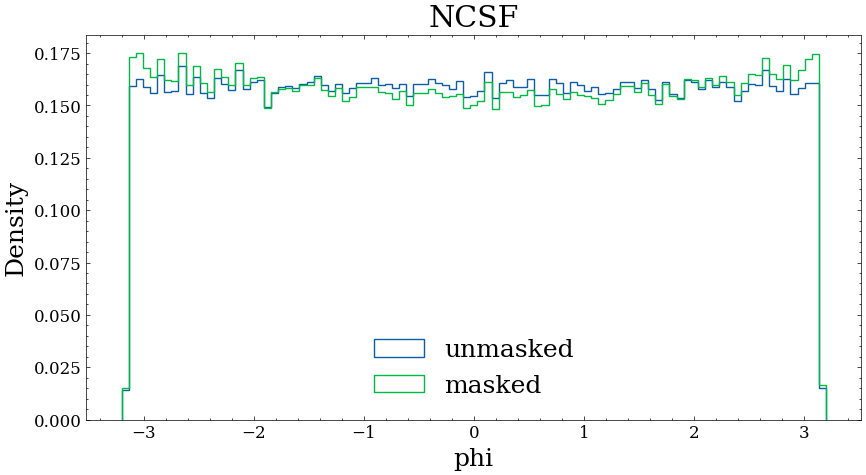

In [8]:



for z in ZUKO_IDS:

    plt.figure(figsize = (10, 5))

    plt.hist(all_samples_dir[z][col_name][:,3], bins = np.linspace(-3.2, 3.2, 100), label = "unmasked", histtype = "step", density = True)
    plt.hist(all_samples_dir_masked[z][col_name][col_name][:,3], bins = np.linspace(-3.2, 3.2, 100), label = "masked", histtype = "step", density = True)

    plt.title(z)
    plt.xlabel("phi")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


In [7]:
print(np.unique(all_data_dir[col_name][:N, -2]))

NameError: name 'N' is not defined

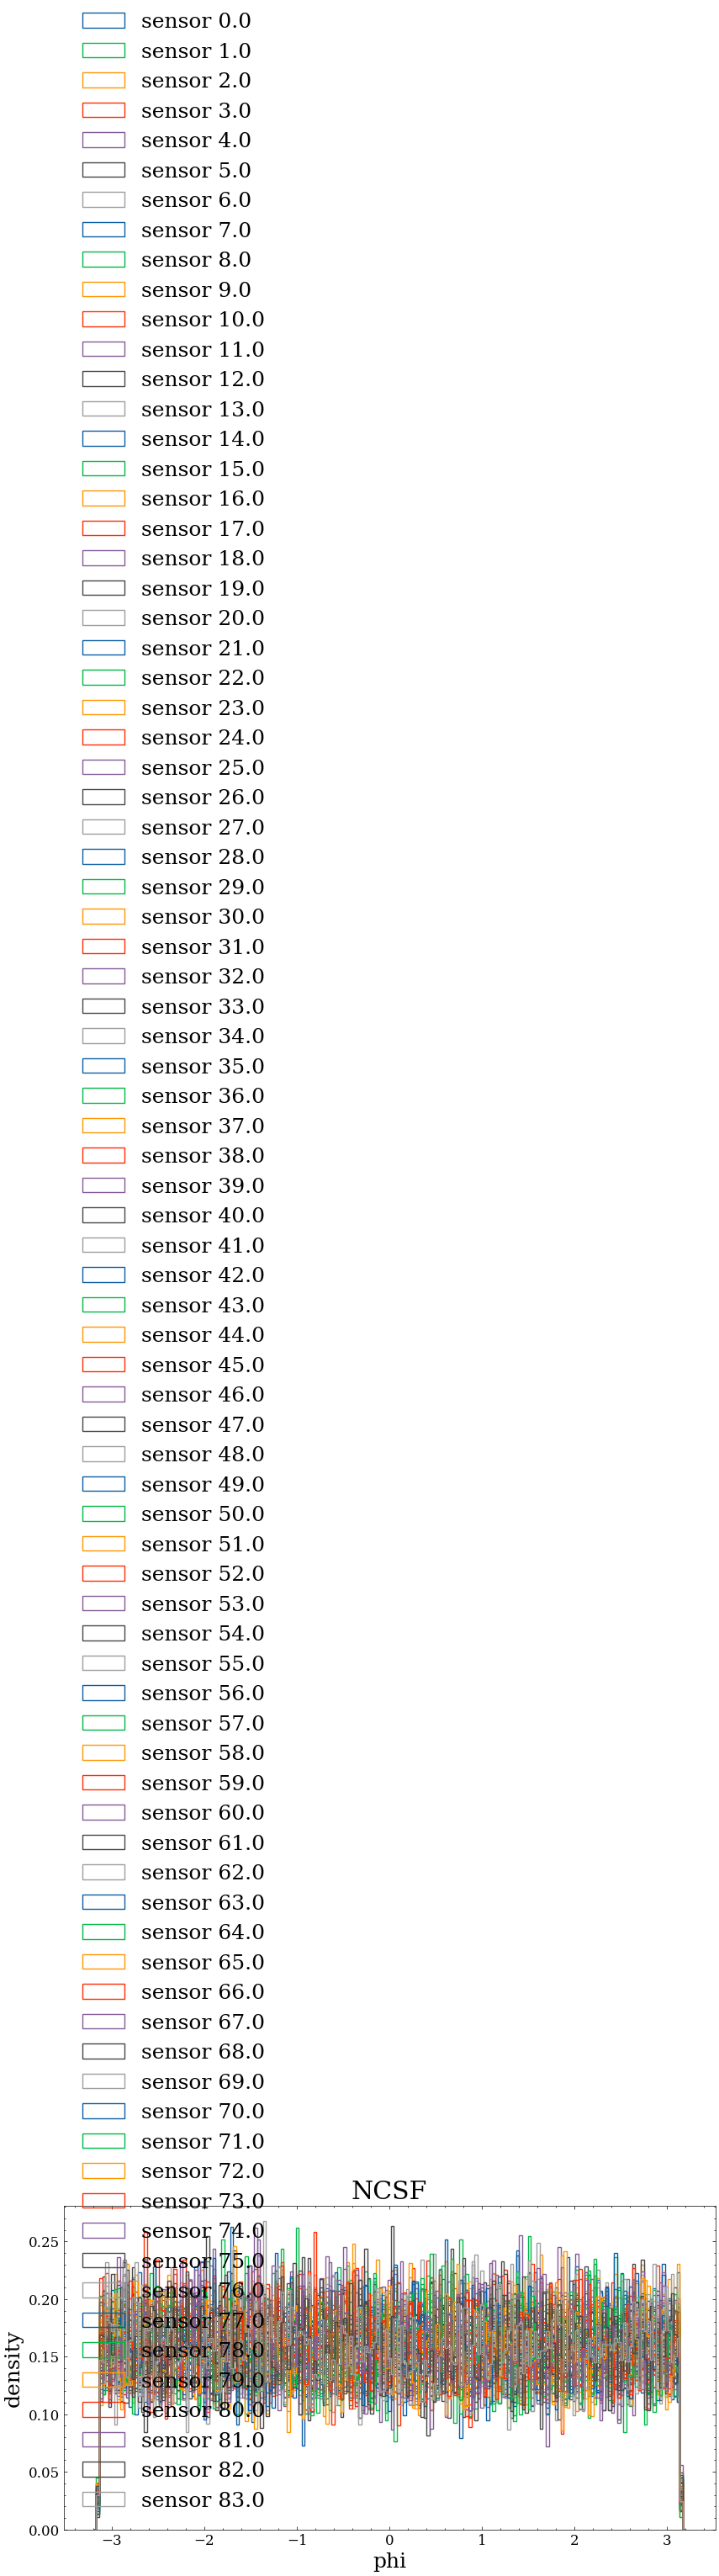

In [9]:
z = "NCSF"




layer_arr = all_samples_dir[z][col_name][:,8]

layers = np.unique(layer_arr)

plt.figure(figsize=(10, 5))

for l in layers:
    mask = layer_arr == l

    plt.hist(
        all_samples_dir[z][col_name][:,3][mask],
        bins=np.linspace(-3.2, 3.2, 200),
        label=f"sensor {l}",
        histtype="step",
        density=True,
    )

plt.title(z)
plt.xlabel("phi")
plt.ylabel("density")
plt.legend()
plt.show()

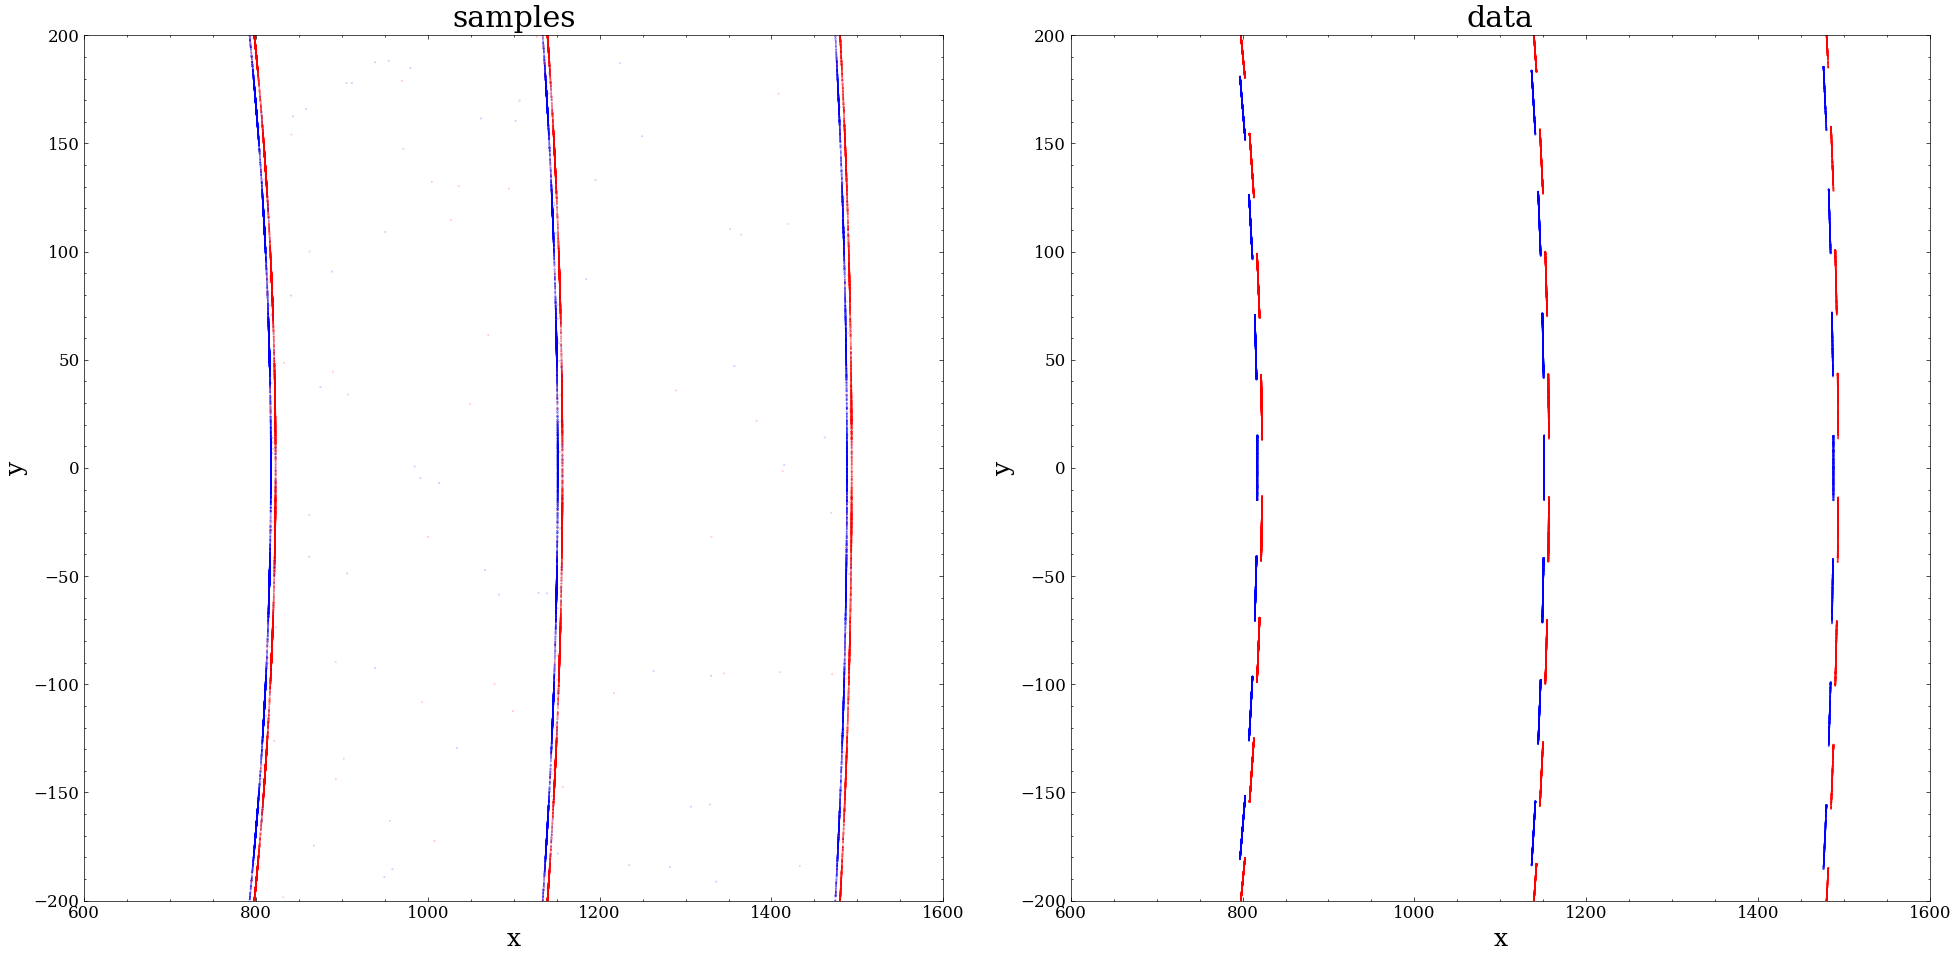

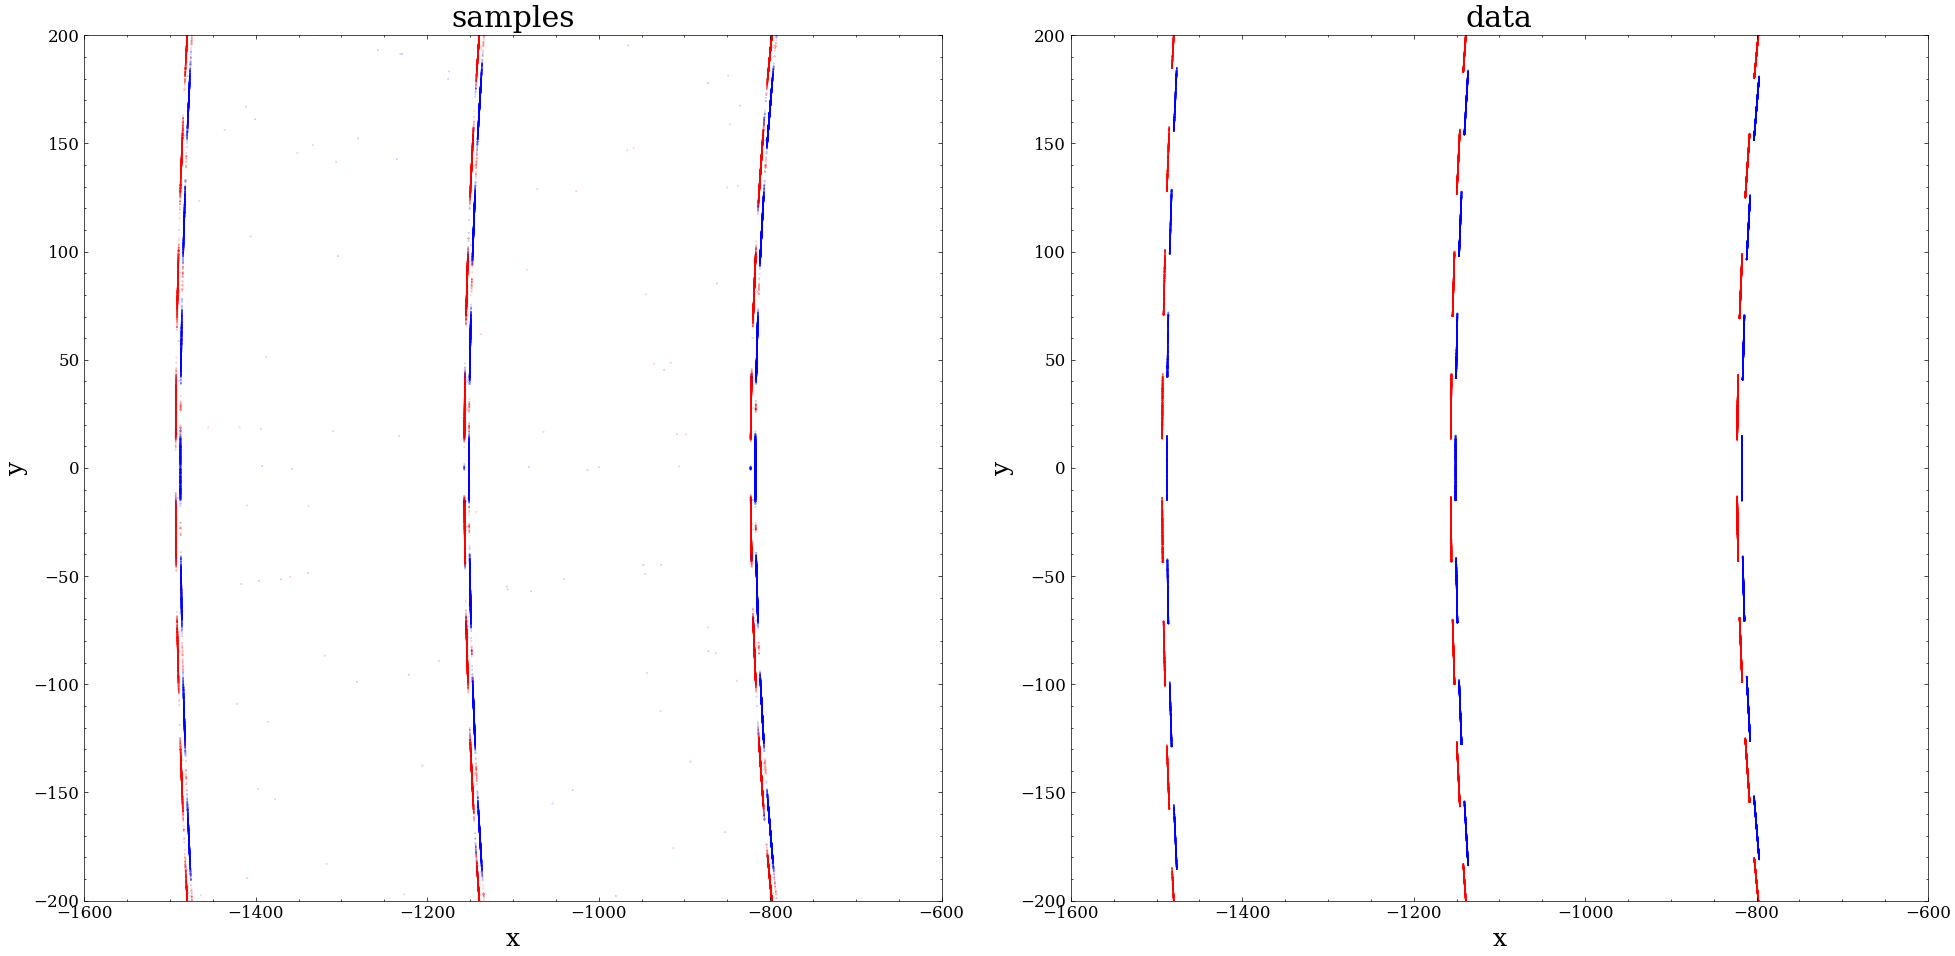

In [10]:
N = 1_000_000  # reduced from 1M for speed

# compute x, y
x      = all_samples_dir[z][col_name][:N, 2] * np.cos(all_samples_dir[z][col_name][:N, 3])
y      = all_samples_dir[z][col_name][:N, 2] * np.sin(all_samples_dir[z][col_name][:N, 3])
x_data = all_data_dir[col_name][:N, 2] * np.cos(all_data_dir[col_name][:N, 3])
y_data = all_data_dir[col_name][:N, 2] * np.sin(all_data_dir[col_name][:N, 3])

# alternating module colors for contrast
c_s = all_samples_dir[z][col_name][:N, -2].astype(int) % 2
c_d = all_data_dir[col_name][:N, -2].astype(int) % 2

scatter_kwargs = dict(s=0.01, cmap='bwr', vmin=0, vmax=1)

# --- positive x side ---
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].scatter(x,      y,      c=c_s, **scatter_kwargs)
ax[1].scatter(x_data, y_data, c=c_d, **scatter_kwargs)
for a in ax:
    a.set_xlim(600, 1600)
    a.set_ylim(-200, 200)
    a.set_xlabel("x")
    a.set_ylabel("y")
ax[0].set_title("samples")
ax[1].set_title("data")
plt.tight_layout()
plt.show()

# --- negative x side ---
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].scatter(x,      y,      c=c_s, **scatter_kwargs)
ax[1].scatter(x_data, y_data, c=c_d, **scatter_kwargs)
for a in ax:
    a.set_xlim(-1600, -600)
    a.set_ylim(-200, 200)
    a.set_xlabel("x")
    a.set_ylabel("y")
ax[0].set_title("samples")
ax[1].set_title("data")
plt.tight_layout()
plt.show()